PREDICT RESTAURENT RATINGS
===========

## Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


## Load Dataset

In [73]:
df = pd.read_csv(r"C:\Users\My PC\Downloads\Dataset .csv", encoding='latin1')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
df.head()

Dataset Shape: (9551, 21)

Columns:
['ï»¿Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Basic Info & Summary

In [75]:
print("=== Dataset Info ===")
df.info()

print("\n=== Statistical Summary ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ï»¿Restaurant ID      9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  

,ï»¿Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


## Check Missing Values

In [77]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': round(missing_pct, 2)})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
          Missing Count  Percentage (%)
Cuisines              9            0.09


## Target Variable Distribution

Total rows         : 9551
Rated restaurants  : 7403
Unrated (removed)  : 2148


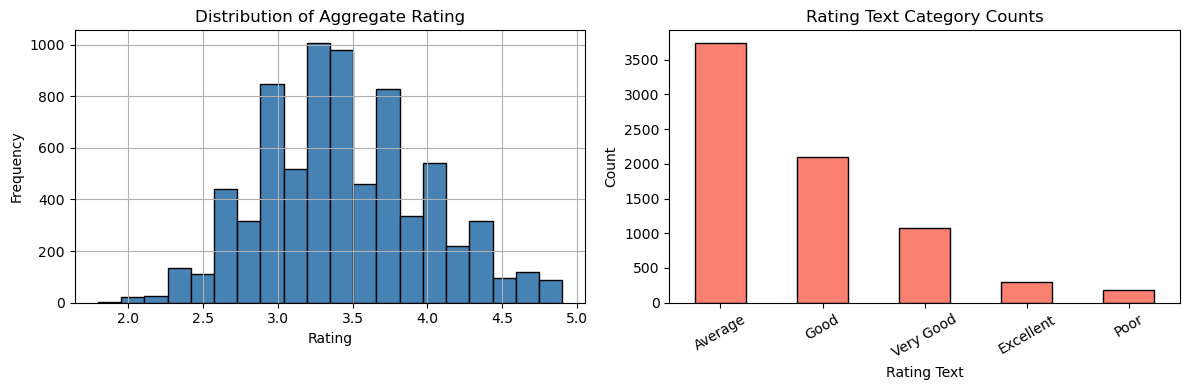

In [79]:
# Remove unrated restaurants (rating == 0)
df_rated = df[df['Aggregate rating'] > 0].copy()
print(f"Total rows         : {len(df)}")
print(f"Rated restaurants  : {len(df_rated)}")
print(f"Unrated (removed)  : {len(df) - len(df_rated)}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_rated['Aggregate rating'].hist(bins=20, color='steelblue', edgecolor='black')
plt.title('Distribution of Aggregate Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df_rated['Rating text'].value_counts().plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Rating Text Category Counts')
plt.xlabel('Rating Text')
plt.ylabel('Count')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Exploratory Visualizations

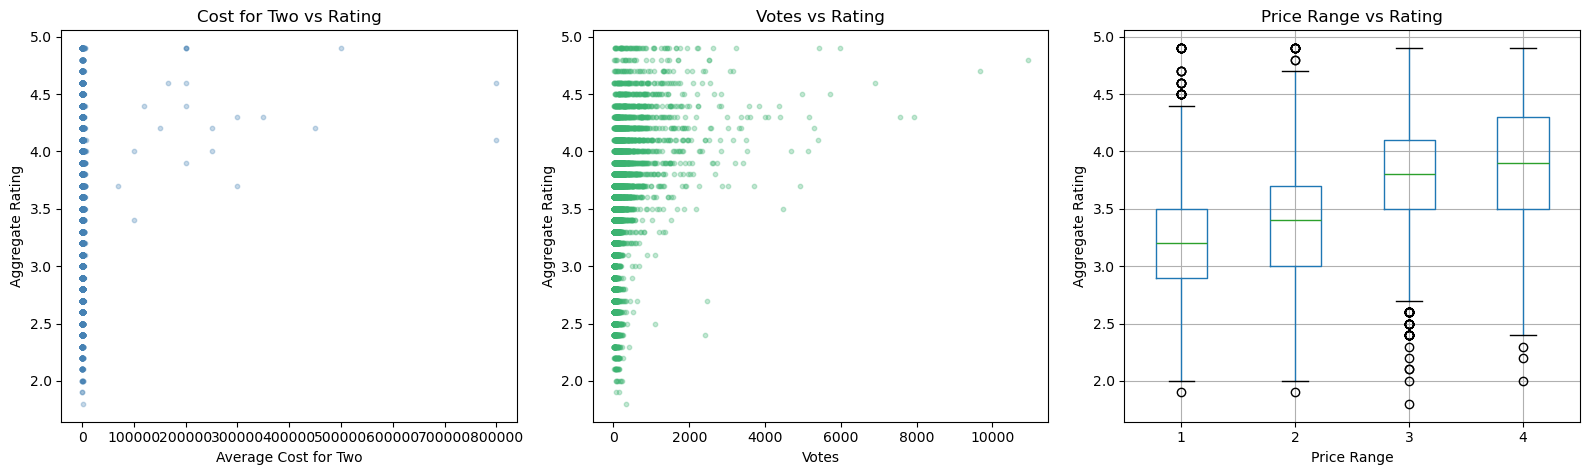

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average cost vs rating
axes[0].scatter(df_rated['Average Cost for two'], df_rated['Aggregate rating'],
                alpha=0.3, color='steelblue', s=10)
axes[0].set_title('Cost for Two vs Rating')
axes[0].set_xlabel('Average Cost for Two')
axes[0].set_ylabel('Aggregate Rating')

# Votes vs rating
axes[1].scatter(df_rated['Votes'], df_rated['Aggregate rating'],
                alpha=0.3, color='mediumseagreen', s=10)
axes[1].set_title('Votes vs Rating')
axes[1].set_xlabel('Votes')
axes[1].set_ylabel('Aggregate Rating')

# Price range vs rating
df_rated.boxplot(column='Aggregate rating', by='Price range', ax=axes[2])
axes[2].set_title('Price Range vs Rating')
axes[2].set_xlabel('Price Range')
axes[2].set_ylabel('Aggregate Rating')
plt.suptitle('')

plt.tight_layout()
plt.show()

## Preprocessing: Handle Missing & Encode Features

In [83]:
df_processed = df_rated.copy()

# Fix column name (BOM character issue)
df_processed.columns = df_processed.columns.str.replace('ï»¿', '', regex=False)

# Fill missing Cuisines with 'Unknown'
df_processed['Cuisines'].fillna('Unknown', inplace=True)
print(f"Missing values after fill: {df_processed.isnull().sum().sum()}")

# Select features for the model
features = [
    'Country Code', 'City', 'Cuisines',
    'Average Cost for two', 'Currency',
    'Has Table booking', 'Has Online delivery',
    'Is delivering now', 'Price range', 'Votes'
]

target = 'Aggregate rating'

X = df_processed[features].copy()
y = df_processed[target].copy()

# Label encode all categorical (object) columns
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))
    print(f"Encoded: {col}")

print("\nFeature matrix shape:", X.shape)
X.head()

Missing values after fill: 0
Encoded: City
Encoded: Cuisines
Encoded: Currency
Encoded: Has Table booking
Encoded: Has Online delivery
Encoded: Is delivering now

Feature matrix shape: (7403, 10)


,Country Code,City,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes
0,162,73,870,1100,0,1,0,0,3,314
1,162,73,1053,1200,0,1,0,0,3,591
2,162,75,1577,4000,0,1,0,0,4,270
3,162,75,1068,1500,0,0,0,0,4,365
4,162,75,1064,1500,0,1,0,0,4,229


## Train-Test Split & Scaling

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape}")
print(f"Testing set  : {X_test.shape}")

# Scale for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Split and scaling done!")

Training set : (5922, 10)
Testing set  : (1481, 10)
Split and scaling done!


## Train All 4 Models

In [87]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("✔ Linear Regression trained.")

# Decision Tree
dt = DecisionTreeRegressor(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("✔ Decision Tree trained.")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("✔ Random Forest trained.")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print("✔ Gradient Boosting trained.")

✔ Linear Regression trained.
✔ Decision Tree trained.
✔ Random Forest trained.
✔ Gradient Boosting trained.


## Evaluate All Models

In [89]:
def evaluate_model(name, y_true, y_pred):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name,
            'MSE':      round(mse, 4),
            'RMSE':     round(rmse, 4),
            'MAE':      round(mae, 4),
            'R² Score': round(r2, 4)}

results = [
    evaluate_model('Linear Regression', y_test, y_pred_lr),
    evaluate_model('Decision Tree',     y_test, y_pred_dt),
    evaluate_model('Random Forest',     y_test, y_pred_rf),
    evaluate_model('Gradient Boosting', y_test, y_pred_gb),
]

results_df = pd.DataFrame(results).sort_values('R² Score', ascending=False).reset_index(drop=True)
print("=== Model Comparison ===")
results_df

=== Model Comparison ===


,Model,MSE,RMSE,MAE,R² Score
0,Random Forest,0.1135,0.3369,0.2508,0.6331
1,Gradient Boosting,0.1135,0.3370,0.2510,0.6329
2,Decision Tree,0.1340,0.3661,0.2745,0.5666
3,Linear Regression,0.1873,0.4328,0.3425,0.3943


## Metrics Bar Chart

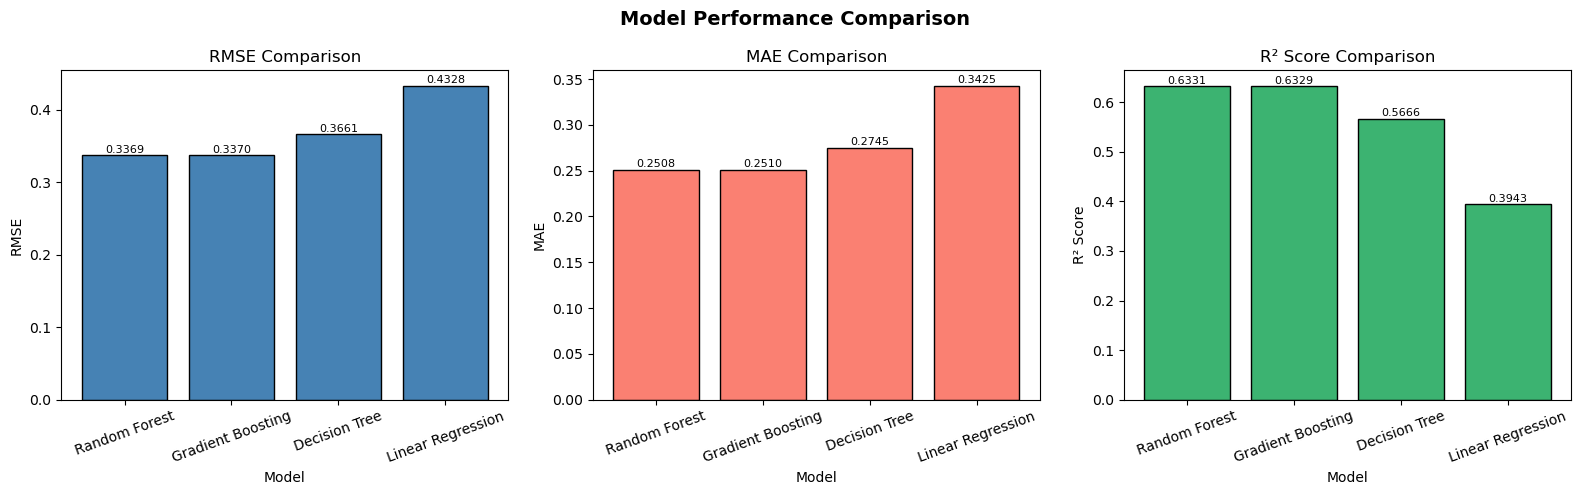

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['RMSE', 'MAE', 'R² Score']
colors  = ['steelblue', 'salmon', 'mediumseagreen']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(results_df['Model'], results_df[metric], color=color, edgecolor='black')
    ax.set_title(f'{metric} Comparison')
    ax.set_xlabel('Model')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Actual vs Predicted Plot (Best Model)

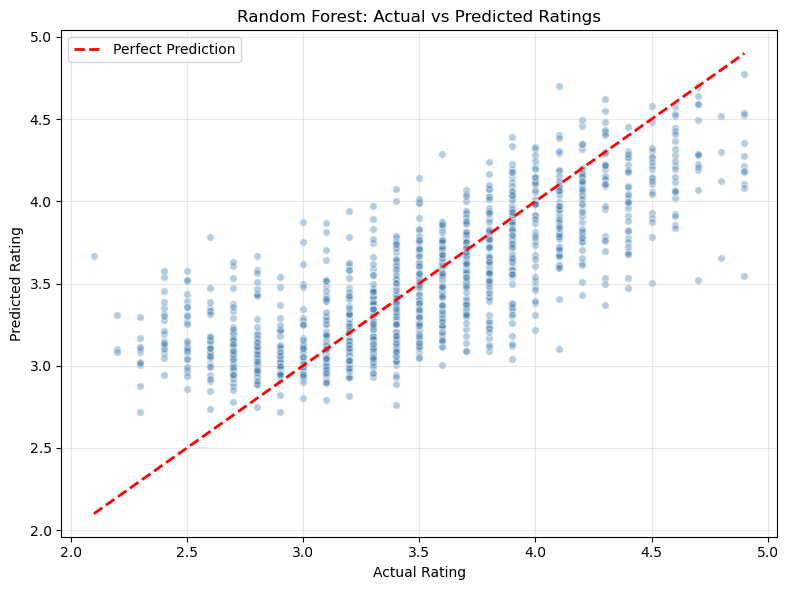

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', edgecolors='white', s=30)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Random Forest: Actual vs Predicted Ratings')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance

=== Feature Importances (Random Forest) ===
             Feature  Importance
               Votes    0.627131
            Cuisines    0.105138
        Country Code    0.104768
                City    0.059235
Average Cost for two    0.059119
            Currency    0.015823
 Has Online delivery    0.013304
         Price range    0.009246
   Has Table booking    0.005691
   Is delivering now    0.000545


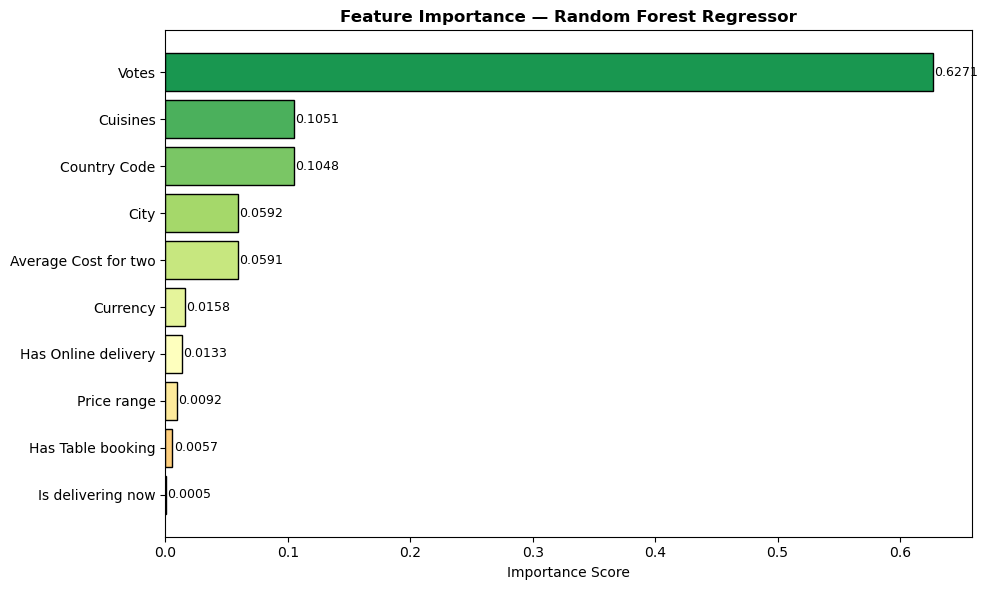

In [95]:
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== Feature Importances (Random Forest) ===")
print(feat_df.to_string(index=False))

plt.figure(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df)))
bars = plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
                color=colors_bar, edgecolor='black')

for bar, val in zip(bars, feat_df['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest Regressor', fontweight='bold')
plt.tight_layout()
plt.show()

## Correlation Heatmap

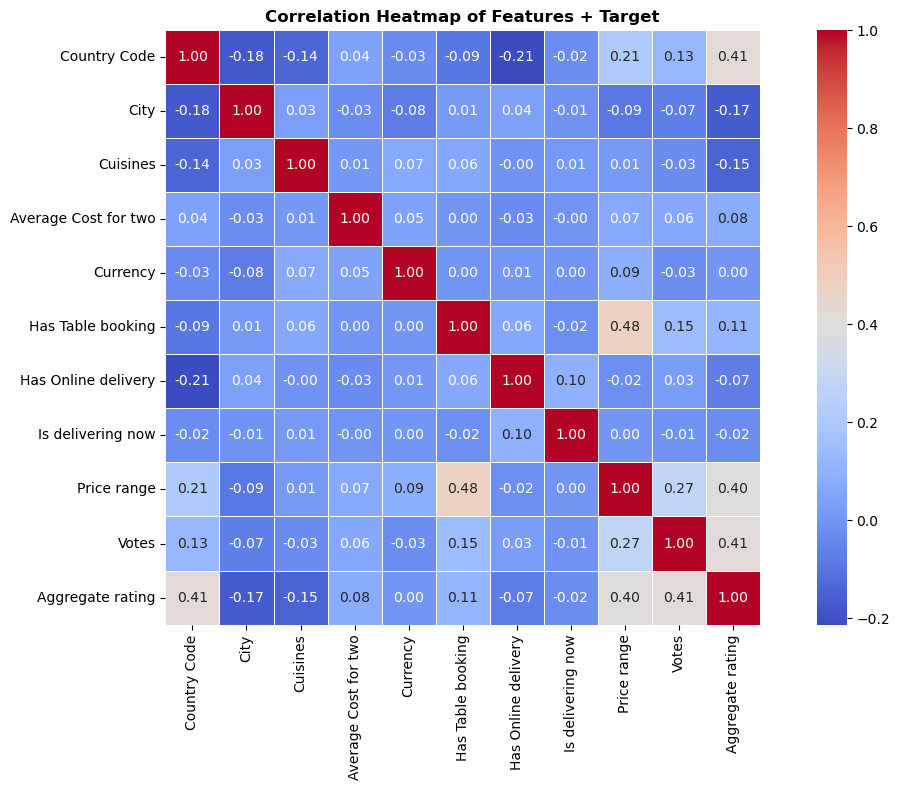

In [97]:
corr_df = X.copy()
corr_df['Aggregate rating'] = y.values

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Features + Target', fontweight='bold')
plt.tight_layout()
plt.show()

## Final Summary

In [99]:
best_row = results_df.iloc[0]

print("=" * 52)
print("            FINAL MODEL SUMMARY")
print("=" * 52)
print(f"  Best Model   : {best_row['Model']}")
print(f"  R² Score     : {best_row['R² Score']}  (1.0 = perfect fit)")
print(f"  RMSE         : {best_row['RMSE']}")
print(f"  MAE          : {best_row['MAE']}")
print("=" * 52)
print(f"  Top Feature  : {feat_df.iloc[0]['Feature']}  ({feat_df.iloc[0]['Importance']:.4f})")
print(f"  2nd Feature  : {feat_df.iloc[1]['Feature']}  ({feat_df.iloc[1]['Importance']:.4f})")
print(f"  3rd Feature  : {feat_df.iloc[2]['Feature']}  ({feat_df.iloc[2]['Importance']:.4f})")
print("=" * 52)
print("\n  Interpretation:")
print("  - Votes & Average Cost are usually top predictors.")
print("  - Higher R² = model captures rating patterns well.")
print("  - Low RMSE means predictions stay close to true rating.")

            FINAL MODEL SUMMARY
  Best Model   : Random Forest
  R² Score     : 0.6331  (1.0 = perfect fit)
  RMSE         : 0.3369
  MAE          : 0.2508
  Top Feature  : Votes  (0.6271)
  2nd Feature  : Cuisines  (0.1051)
  3rd Feature  : Country Code  (0.1048)

  Interpretation:
  - Votes & Average Cost are usually top predictors.
  - Higher R² = model captures rating patterns well.
  - Low RMSE means predictions stay close to true rating.
